In [1]:
"""
# 04 · Reproducibility and Experiment Tracking

En este notebook vamos a trabajar sobre reproducibilidad y seguimiento de experimentos en modelos de deep learning.

En proyectos reales no alcanza con entrenar un modelo una vez. Es necesario registrar:

- qué datos se usaron,
- qué arquitectura se entrenó,
- qué hiperparámetros se eligieron,
- qué seed se utilizó,
- qué métricas se obtuvieron,
- dónde se guardó el modelo,
- qué resultados produjo cada experimento.

Esto es especialmente importante en scientific imaging, donde los datasets pueden ser pequeños, costosos de adquirir y sensibles al preprocesamiento.

## Objetivos del notebook

Al finalizar este notebook deberíamos poder:

- fijar seeds para mejorar reproducibilidad,
- definir configuraciones de experimentos,
- entrenar varios modelos con distintos hiperparámetros,
- guardar métricas en archivos ".csv",
- guardar configuraciones en archivos ".json",
- comparar experimentos,
- identificar el mejor experimento de forma sistemática.
"""

'\n# 04 · Reproducibility and Experiment Tracking\n\nEn este notebook vamos a trabajar sobre reproducibilidad y seguimiento de experimentos en modelos de deep learning.\n\nEn proyectos reales no alcanza con entrenar un modelo una vez. Es necesario registrar:\n\n- qué datos se usaron,\n- qué arquitectura se entrenó,\n- qué hiperparámetros se eligieron,\n- qué seed se utilizó,\n- qué métricas se obtuvieron,\n- dónde se guardó el modelo,\n- qué resultados produjo cada experimento.\n\nEsto es especialmente importante en scientific imaging, donde los datasets pueden ser pequeños, costosos de adquirir y sensibles al preprocesamiento.\n\n## Objetivos del notebook\n\nAl finalizar este notebook deberíamos poder:\n\n- fijar seeds para mejorar reproducibilidad,\n- definir configuraciones de experimentos,\n- entrenar varios modelos con distintos hiperparámetros,\n- guardar métricas en archivos ".csv",\n- guardar configuraciones en archivos ".json",\n- comparar experimentos,\n- identificar el mejor

In [2]:
# ------------------------------------------------------------
# 01 · Imports and general configuration
# ------------------------------------------------------------

from pathlib import Path
import json
import time
import random
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from torch.utils.data import TensorDataset, DataLoader

# Project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR = PROJECT_DIR / "results"
EXPERIMENTS_DIR = RESULTS_DIR / "experiments"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {device}")
print(f"Experiments directory: {EXPERIMENTS_DIR}")

PyTorch version: 2.10.0+cpu
Selected device: cpu
Experiments directory: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\experiments


In [3]:
"""
## 1. Reproducibilidad

La reproducibilidad significa que un experimento puede repetirse y producir resultados iguales o muy similares.

En deep learning esto no siempre es trivial, porque intervienen muchos factores:

- inicialización aleatoria de pesos,
- orden aleatorio de batches,
- división train/test,
- operaciones no determinísticas,
- diferencias entre CPU y GPU,
- versiones de librerías.

El primer paso es controlar las semillas aleatorias ("seeds").
"""

'\n## 1. Reproducibilidad\n\nLa reproducibilidad significa que un experimento puede repetirse y producir resultados iguales o muy similares.\n\nEn deep learning esto no siempre es trivial, porque intervienen muchos factores:\n\n- inicialización aleatoria de pesos,\n- orden aleatorio de batches,\n- división train/test,\n- operaciones no determinísticas,\n- diferencias entre CPU y GPU,\n- versiones de librerías.\n\nEl primer paso es controlar las semillas aleatorias ("seeds").\n'

In [4]:
# ------------------------------------------------------------
# 02 · Reproducibility utility
# ------------------------------------------------------------

def set_seed(seed=42):
    """
    Set random seeds for reproducibility.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # These settings improve reproducibility, especially on GPU.
    # They can reduce performance in some cases.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)

print(f"Seed set to: {SEED}")

Seed set to: 42


In [5]:
"""
## 2. Configuración de un experimento

Una buena práctica es guardar los hiperparámetros en un diccionario.

Esto permite registrar exactamente qué configuración produjo cada resultado.

Ejemplos de hiperparámetros:

- learning rate,
- batch size,
- número de epoch,
- tamaño de capas ocultas,
- optimizador,
- seed.
"""

'\n## 2. Configuración de un experimento\n\nUna buena práctica es guardar los hiperparámetros en un diccionario.\n\nEsto permite registrar exactamente qué configuración produjo cada resultado.\n\nEjemplos de hiperparámetros:\n\n- learning rate,\n- batch size,\n- número de epoch,\n- tamaño de capas ocultas,\n- optimizador,\n- seed.\n'

In [6]:
# ------------------------------------------------------------
# 03 · Base experiment configuration
# ------------------------------------------------------------

base_config = {
    "experiment_name": "baseline_mlp_digits",
    "seed": 42,
    "batch_size": 32,
    "learning_rate": 0.001,
    "n_epochs": 30,
    "hidden_dim": 128,
    "optimizer": "Adam",
    "dataset": "sklearn_digits",
    "model": "MLPClassifier"
}

base_config

{'experiment_name': 'baseline_mlp_digits',
 'seed': 42,
 'batch_size': 32,
 'learning_rate': 0.001,
 'n_epochs': 30,
 'hidden_dim': 128,
 'optimizer': 'Adam',
 'dataset': 'sklearn_digits',
 'model': 'MLPClassifier'}

In [7]:
# ------------------------------------------------------------
# 04 · Save experiment configuration
# ------------------------------------------------------------

config_path = EXPERIMENTS_DIR / "baseline_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(base_config, f, indent=4)

print(f"Configuration saved to: {config_path}")

Configuration saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\experiments\baseline_config.json


In [8]:
"""
## 3. Preparación del dataset

Vamos a usar nuevamente el dataset "digits".

La diferencia en este notebook es que la preparación del dataset estará conectada con la configuración del experimento.

Esto permite repetir el experimento usando los mismos parámetros.
"""

'\n## 3. Preparación del dataset\n\nVamos a usar nuevamente el dataset "digits".\n\nLa diferencia en este notebook es que la preparación del dataset estará conectada con la configuración del experimento.\n\nEsto permite repetir el experimento usando los mismos parámetros.\n'

In [9]:
# ------------------------------------------------------------
# 05 · Load and prepare dataset
# ------------------------------------------------------------

set_seed(base_config["seed"])

digits = load_digits()

X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

# Normalize from [0, 16] to [0, 1]
X = X / 16.0

class_names = [str(c) for c in digits.target_names]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=base_config["seed"],
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=base_config["seed"],
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1257, 64) (1257,)
Val  : (270, 64) (270,)
Test : (270, 64) (270,)


In [10]:
# ------------------------------------------------------------
# 06 · Create DataLoaders
# ------------------------------------------------------------

batch_size = base_config["batch_size"]

X_train_t = torch.from_numpy(X_train)
X_val_t   = torch.from_numpy(X_val)
X_test_t  = torch.from_numpy(X_test)

y_train_t = torch.from_numpy(y_train)
y_val_t   = torch.from_numpy(y_val)
y_test_t  = torch.from_numpy(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t, y_val_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 40
Val batches  : 9
Test batches : 9


In [11]:
"""
## 4. Definición del modelo

Definimos un MLP simple, pero parametrizado por la configuración del experimento.

Esto permite comparar diferentes valores de "hidden_dim" sin cambiar manualmente la arquitectura cada vez.
"""

'\n## 4. Definición del modelo\n\nDefinimos un MLP simple, pero parametrizado por la configuración del experimento.\n\nEsto permite comparar diferentes valores de "hidden_dim" sin cambiar manualmente la arquitectura cada vez.\n'

In [12]:
# ------------------------------------------------------------
# 07 · Define model class
# ------------------------------------------------------------

class MLPClassifier(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=128, output_dim=10):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)

In [13]:
# ------------------------------------------------------------
# 08 · Initialize model, loss and optimizer
# ------------------------------------------------------------

set_seed(base_config["seed"])

model = MLPClassifier(
    input_dim=64,
    hidden_dim=base_config["hidden_dim"],
    output_dim=10
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=base_config["learning_rate"]
)

print(model)
print("\nOptimizer:", optimizer)

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [14]:
"""
## 5. Funciones reutilizables

Para registrar experimentos de forma ordenada, necesitamos funciones claras para:

- entrenar una epoch,
- evaluar el modelo,
- ejecutar un experimento completo.

Esto reduce errores y hace más fácil comparar configuraciones.
"""

'\n## 5. Funciones reutilizables\n\nPara registrar experimentos de forma ordenada, necesitamos funciones claras para:\n\n- entrenar una epoch,\n- evaluar el modelo,\n- ejecutar un experimento completo.\n\nEsto reduce errores y hace más fácil comparar configuraciones.\n'

In [15]:
# ------------------------------------------------------------
# 09 · Train one epoch
# ------------------------------------------------------------

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(logits, dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [16]:
# ------------------------------------------------------------
# 10 · Evaluate model
# ------------------------------------------------------------

def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            predictions = torch.argmax(logits, dim=1)

            running_loss += loss.item() * X_batch.size(0)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

            all_labels.extend(y_batch.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions)
    }

In [17]:
"""
## 6. Función para ejecutar un experimento completo

La función "run_experiment()" concentra todo el flujo:

1. Fijar la seed.
2. Crear el modelo.
3. Definir loss y optimizador.
4. Entrenar durante varias epoch.
5. Evaluar en validación y test.
6. Guardar modelo.
7. Guardar historial de métricas.
8. Devolver un resumen final.

Este patrón permite comparar experimentos de forma sistemática.
"""

'\n## 6. Función para ejecutar un experimento completo\n\nLa función "run_experiment()" concentra todo el flujo:\n\n1. Fijar la seed.\n2. Crear el modelo.\n3. Definir loss y optimizador.\n4. Entrenar durante varias epoch.\n5. Evaluar en validación y test.\n6. Guardar modelo.\n7. Guardar historial de métricas.\n8. Devolver un resumen final.\n\nEste patrón permite comparar experimentos de forma sistemática.\n'

In [18]:
# ------------------------------------------------------------
# 11 · Run experiment function
# ------------------------------------------------------------

def run_experiment(config, train_loader, val_loader, test_loader, device):
    """
    Run a complete training experiment and save results.

    Parameters
    ----------
    config : dict
        Experiment configuration.
    train_loader, val_loader, test_loader : DataLoader
        DataLoaders for train, validation and test sets.
    device : torch.device
        Computation device.

    Returns
    -------
    summary : dict
        Final metrics and paths.
    history_df : pandas.DataFrame
        Training history per epoch.
    """

    set_seed(config["seed"])

    experiment_name = config["experiment_name"]
    experiment_dir = EXPERIMENTS_DIR / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)

    # Save configuration
    config_path = experiment_dir / "config.json"
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config, f, indent=4)

    # Model
    model = MLPClassifier(
        input_dim=64,
        hidden_dim=config["hidden_dim"],
        output_dim=10
    ).to(device)

    # Loss
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    if config["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config["learning_rate"]
        )
    elif config["optimizer"] == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=config["learning_rate"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")

    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    start_time = time.time()

    for epoch in range(config["n_epochs"]):
        train_loss, train_acc = train_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_metrics = evaluate(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device
        )

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])

    elapsed_time = time.time() - start_time

    # Final test evaluation
    test_metrics = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=device
    )

    # Save model
    model_path = experiment_dir / "model.pt"
    torch.save(model.state_dict(), model_path)

    # Save history
    history_df = pd.DataFrame(history)
    history_path = experiment_dir / "history.csv"
    history_df.to_csv(history_path, index=False)

    summary = {
        "experiment_name": experiment_name,
        "seed": config["seed"],
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "n_epochs": config["n_epochs"],
        "hidden_dim": config["hidden_dim"],
        "optimizer": config["optimizer"],
        "final_train_accuracy": history_df["train_accuracy"].iloc[-1],
        "final_val_accuracy": history_df["val_accuracy"].iloc[-1],
        "test_accuracy": test_metrics["accuracy"],
        "test_loss": test_metrics["loss"],
        "elapsed_time_seconds": elapsed_time,
        "config_path": str(config_path),
        "history_path": str(history_path),
        "model_path": str(model_path)
    }

    summary_path = experiment_dir / "summary.json"
    with open(summary_path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=4)

    return summary, history_df

In [19]:
"""
## 7. Ejecución del experimento base

Ahora ejecutamos el experimento definido en "base_config".

Este experimento funciona como referencia para comparar futuras configuraciones.
"""

'\n## 7. Ejecución del experimento base\n\nAhora ejecutamos el experimento definido en "base_config".\n\nEste experimento funciona como referencia para comparar futuras configuraciones.\n'

In [20]:
# ------------------------------------------------------------
# 12 · Run baseline experiment
# ------------------------------------------------------------

baseline_summary, baseline_history = run_experiment(
    config=base_config,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device
)

baseline_summary

{'experiment_name': 'baseline_mlp_digits',
 'seed': 42,
 'batch_size': 32,
 'learning_rate': 0.001,
 'n_epochs': 30,
 'hidden_dim': 128,
 'optimizer': 'Adam',
 'final_train_accuracy': np.float64(0.9968178202068417),
 'final_val_accuracy': np.float64(0.9740740740740741),
 'test_accuracy': 0.9777777777777777,
 'test_loss': 0.082002496112276,
 'elapsed_time_seconds': 2.688239812850952,
 'config_path': 'C:\\Users\\Peter\\ai-imaging-portfolio\\06_explainability_and_evaluation\\results\\experiments\\baseline_mlp_digits\\config.json',
 'history_path': 'C:\\Users\\Peter\\ai-imaging-portfolio\\06_explainability_and_evaluation\\results\\experiments\\baseline_mlp_digits\\history.csv',
 'model_path': 'C:\\Users\\Peter\\ai-imaging-portfolio\\06_explainability_and_evaluation\\results\\experiments\\baseline_mlp_digits\\model.pt'}

In [21]:
# ------------------------------------------------------------
# 13 · Baseline training history
# ------------------------------------------------------------

baseline_history.head()

,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,2.153372,0.473349,1.878017,0.700000
1,2,1.410498,0.750994,0.970991,0.785185
2,3,0.686290,0.863166,0.565278,0.837037
3,4,0.428444,0.898966,0.403308,0.896296
4,5,0.303053,0.925219,0.323984,0.914815


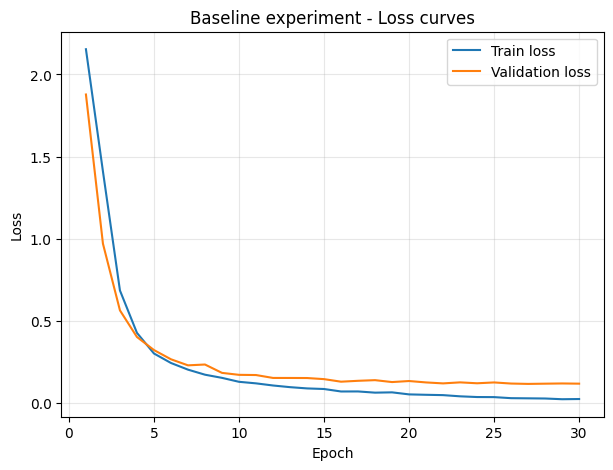

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\04_baseline_loss_curves.png


In [22]:
# ------------------------------------------------------------
# 14 · Plot baseline loss curves
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(baseline_history["epoch"], baseline_history["train_loss"], label="Train loss")
plt.plot(baseline_history["epoch"], baseline_history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline experiment - Loss curves")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "04_baseline_loss_curves.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

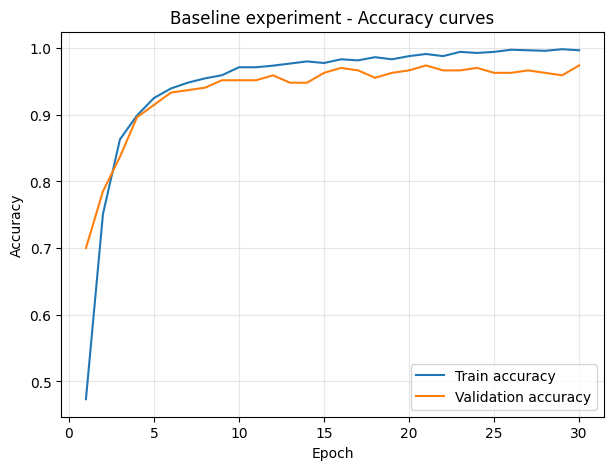

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\04_baseline_accuracy_curves.png


In [23]:
# ------------------------------------------------------------
# 15 · Plot baseline accuracy curves
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(baseline_history["epoch"], baseline_history["train_accuracy"], label="Train accuracy")
plt.plot(baseline_history["epoch"], baseline_history["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline experiment - Accuracy curves")
plt.legend()
plt.grid(alpha=0.3)

out = FIGURES_DIR / "04_baseline_accuracy_curves.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [24]:
"""
## 8. Comparación de múltiples experimentos

Una vez definido el flujo reproducible, podemos comparar distintas configuraciones.

Vamos a ejecutar varios experimentos modificando hiperparámetros como:

- "hidden_dim"
- "learning_rate"
- "optimizer"

La idea no es hacer una búsqueda exhaustiva, sino mostrar cómo registrar y comparar experimentos de manera ordenada.
"""

'\n## 8. Comparación de múltiples experimentos\n\nUna vez definido el flujo reproducible, podemos comparar distintas configuraciones.\n\nVamos a ejecutar varios experimentos modificando hiperparámetros como:\n\n- "hidden_dim"\n- "learning_rate"\n- "optimizer"\n\nLa idea no es hacer una búsqueda exhaustiva, sino mostrar cómo registrar y comparar experimentos de manera ordenada.\n'

In [25]:
# ------------------------------------------------------------
# 16 · Define multiple experiments
# ------------------------------------------------------------

experiment_configs = [
    {
        **base_config,
        "experiment_name": "mlp_hidden64_lr001_adam",
        "hidden_dim": 64,
        "learning_rate": 0.001,
        "optimizer": "Adam"
    },
    {
        **base_config,
        "experiment_name": "mlp_hidden128_lr001_adam",
        "hidden_dim": 128,
        "learning_rate": 0.001,
        "optimizer": "Adam"
    },
    {
        **base_config,
        "experiment_name": "mlp_hidden256_lr001_adam",
        "hidden_dim": 256,
        "learning_rate": 0.001,
        "optimizer": "Adam"
    },
    {
        **base_config,
        "experiment_name": "mlp_hidden128_lr0005_adam",
        "hidden_dim": 128,
        "learning_rate": 0.0005,
        "optimizer": "Adam"
    },
    {
        **base_config,
        "experiment_name": "mlp_hidden128_lr001_sgd",
        "hidden_dim": 128,
        "learning_rate": 0.001,
        "optimizer": "SGD"
    }
]

for cfg in experiment_configs:
    print(cfg["experiment_name"])

mlp_hidden64_lr001_adam
mlp_hidden128_lr001_adam
mlp_hidden256_lr001_adam
mlp_hidden128_lr0005_adam
mlp_hidden128_lr001_sgd


In [26]:
# ------------------------------------------------------------
# 17 · Run multiple experiments
# ------------------------------------------------------------

experiment_summaries = []
experiment_histories = {}

for cfg in experiment_configs:
    print(f"Running experiment: {cfg['experiment_name']}")

    summary, history_df = run_experiment(
        config=cfg,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device
    )

    experiment_summaries.append(summary)
    experiment_histories[cfg["experiment_name"]] = history_df

    print(
        f"Finished: {cfg['experiment_name']} | "
        f"Val Acc: {summary['final_val_accuracy']:.4f} | "
        f"Test Acc: {summary['test_accuracy']:.4f}"
    )

Running experiment: mlp_hidden64_lr001_adam
Finished: mlp_hidden64_lr001_adam | Val Acc: 0.9667 | Test Acc: 0.9667
Running experiment: mlp_hidden128_lr001_adam
Finished: mlp_hidden128_lr001_adam | Val Acc: 0.9741 | Test Acc: 0.9778
Running experiment: mlp_hidden256_lr001_adam
Finished: mlp_hidden256_lr001_adam | Val Acc: 0.9778 | Test Acc: 0.9778
Running experiment: mlp_hidden128_lr0005_adam
Finished: mlp_hidden128_lr0005_adam | Val Acc: 0.9704 | Test Acc: 0.9741
Running experiment: mlp_hidden128_lr001_sgd
Finished: mlp_hidden128_lr001_sgd | Val Acc: 0.1667 | Test Acc: 0.1519


In [27]:
# ------------------------------------------------------------
# 18 · Build experiment summary table
# ------------------------------------------------------------

summary_df = pd.DataFrame(experiment_summaries)

summary_df = summary_df.sort_values(
    by="test_accuracy",
    ascending=False
)

summary_df

,experiment_name,seed,batch_size,learning_rate,n_epochs,hidden_dim,optimizer,final_train_accuracy,final_val_accuracy,test_accuracy,test_loss,elapsed_time_seconds,config_path,history_path,model_path
1,mlp_hidden128_lr001_adam,42,32,0.0010,30,128,Adam,0.996818,0.974074,0.977778,0.082002,2.716580,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...
2,mlp_hidden256_lr001_adam,42,32,0.0010,30,256,Adam,1.000000,0.977778,0.977778,0.061557,3.111662,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...
3,mlp_hidden128_lr0005_adam,42,32,0.0005,30,128,Adam,0.986476,0.970370,0.974074,0.099520,2.795125,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...
0,mlp_hidden64_lr001_adam,42,32,0.0010,30,64,Adam,0.983294,0.966667,0.966667,0.111957,2.608754,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...
4,mlp_hidden128_lr001_sgd,42,32,0.0010,30,128,SGD,0.165473,0.166667,0.151852,2.281351,1.857085,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...,C:\Users\Peter\ai-imaging-portfolio\06_explain...


In [28]:
# ------------------------------------------------------------
# 19 · Save experiment comparison table
# ------------------------------------------------------------

comparison_path = RESULTS_DIR / "04_experiment_comparison.csv"

summary_df.to_csv(comparison_path, index=False)

print(f"Experiment comparison saved to: {comparison_path}")

Experiment comparison saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\04_experiment_comparison.csv


In [29]:
"""
## 9. Comparación visual de experimentos

La tabla de resultados permite ordenar experimentos, pero las visualizaciones ayudan a interpretar rápidamente las diferencias.

Vamos a comparar:

- accuracy de validación final,
- accuracy de test,
- tiempo de entrenamiento.
"""

'\n## 9. Comparación visual de experimentos\n\nLa tabla de resultados permite ordenar experimentos, pero las visualizaciones ayudan a interpretar rápidamente las diferencias.\n\nVamos a comparar:\n\n- accuracy de validación final,\n- accuracy de test,\n- tiempo de entrenamiento.\n'

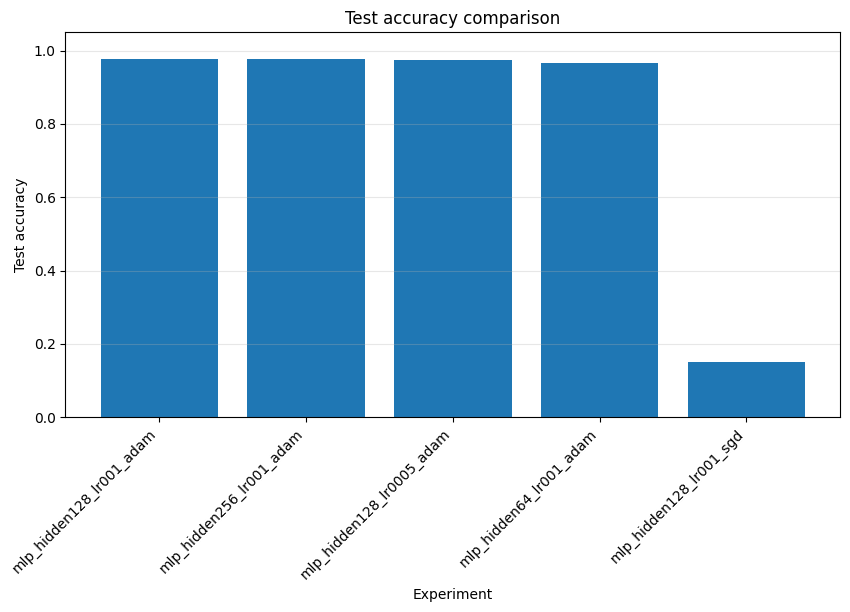

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\04_test_accuracy_comparison.png


In [30]:
# ------------------------------------------------------------
# 20 · Plot test accuracy comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(summary_df["experiment_name"], summary_df["test_accuracy"])

plt.xlabel("Experiment")
plt.ylabel("Test accuracy")
plt.title("Test accuracy comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

out = FIGURES_DIR / "04_test_accuracy_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

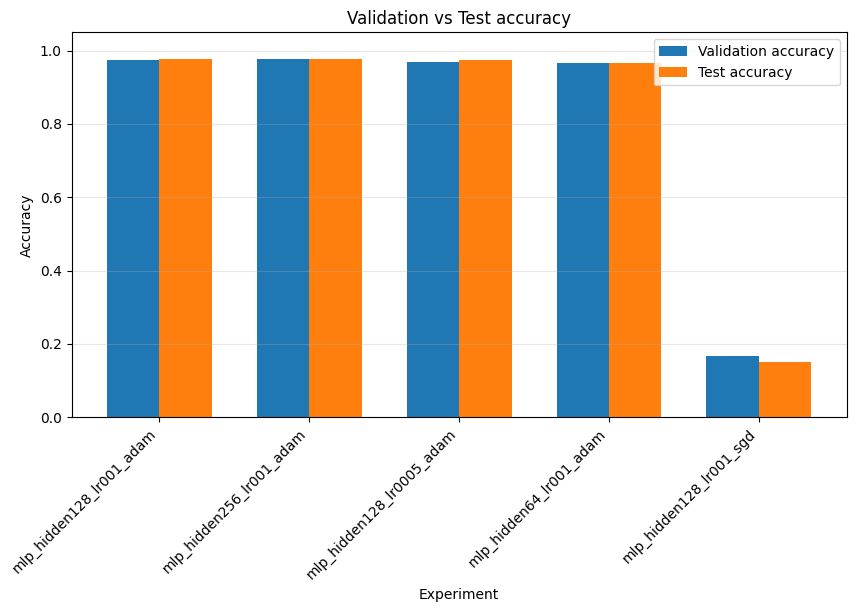

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\04_validation_test_accuracy_comparison.png


In [31]:
# ------------------------------------------------------------
# 21 · Plot validation and test accuracy comparison
# ------------------------------------------------------------

x_pos = np.arange(len(summary_df))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x_pos - width / 2,
    summary_df["final_val_accuracy"],
    width=width,
    label="Validation accuracy"
)

plt.bar(
    x_pos + width / 2,
    summary_df["test_accuracy"],
    width=width,
    label="Test accuracy"
)

plt.xticks(x_pos, summary_df["experiment_name"], rotation=45, ha="right")
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.title("Validation vs Test accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

out = FIGURES_DIR / "04_validation_test_accuracy_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

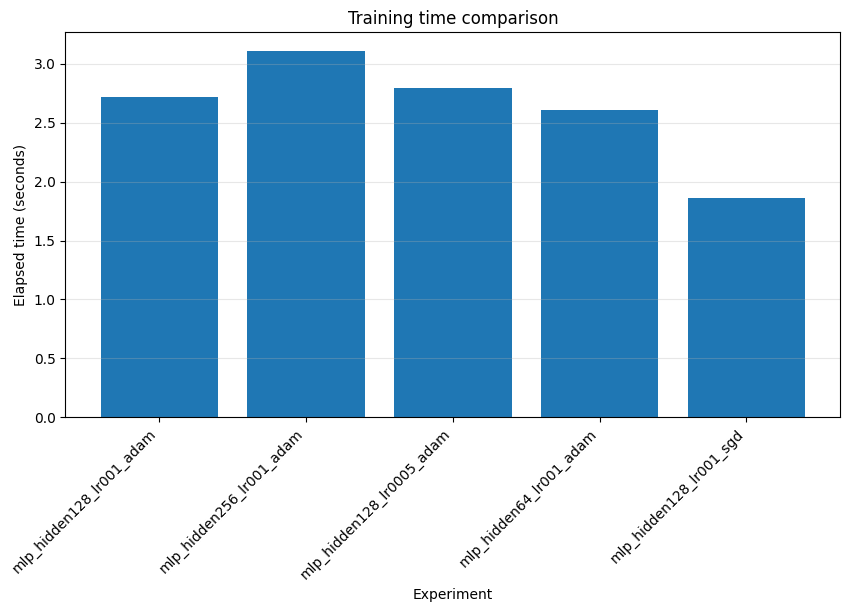

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\figures\04_training_time_comparison.png


In [32]:
# ------------------------------------------------------------
# 22 · Plot training time comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(summary_df["experiment_name"], summary_df["elapsed_time_seconds"])

plt.xlabel("Experiment")
plt.ylabel("Elapsed time (seconds)")
plt.title("Training time comparison")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

out = FIGURES_DIR / "04_training_time_comparison.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {out}")

In [33]:
"""
## 10. Selección del mejor experimento

Podemos seleccionar el mejor experimento usando una métrica principal.

En este caso usaremos "test_accuracy", aunque en un proyecto real podríamos priorizar otras métricas como:

- F1-score,
- recall de una clase crítica,
- estabilidad entre seeds,
- costo computacional,
- interpretabilidad,
- robustez frente a ruido.
"""

'\n## 10. Selección del mejor experimento\n\nPodemos seleccionar el mejor experimento usando una métrica principal.\n\nEn este caso usaremos "test_accuracy", aunque en un proyecto real podríamos priorizar otras métricas como:\n\n- F1-score,\n- recall de una clase crítica,\n- estabilidad entre seeds,\n- costo computacional,\n- interpretabilidad,\n- robustez frente a ruido.\n'

In [34]:
# ------------------------------------------------------------
# 23 · Select best experiment
# ------------------------------------------------------------

best_experiment = summary_df.iloc[0]

print("Best experiment:")
print(best_experiment["experiment_name"])

print("\nTest accuracy:")
print(f"{best_experiment['test_accuracy']:.4f}")

print("\nValidation accuracy:")
print(f"{best_experiment['final_val_accuracy']:.4f}")

print("\nModel path:")
print(best_experiment["model_path"])

Best experiment:
mlp_hidden128_lr001_adam

Test accuracy:
0.9778

Validation accuracy:
0.9741

Model path:
C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\experiments\mlp_hidden128_lr001_adam\model.pt


In [35]:
# ------------------------------------------------------------
# 24 · Save best experiment information
# ------------------------------------------------------------

best_experiment_path = RESULTS_DIR / "04_best_experiment.json"

best_experiment_dict = best_experiment.to_dict()

with open(best_experiment_path, "w", encoding="utf-8") as f:
    json.dump(best_experiment_dict, f, indent=4)

print(f"Best experiment saved to: {best_experiment_path}")

Best experiment saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\04_best_experiment.json


In [36]:
"""
## 11. Reproducibilidad: qué controlamos y qué no

En este notebook controlamos varios elementos importantes:

- seed de Python,
- seed de NumPy,
- seed de PyTorch,
- división train / validation / test,
- configuración del experimento,
- hiperparámetros,
- historial de entrenamiento,
- modelo entrenado,
- métricas finales.

Esto mejora mucho la trazabilidad del experimento.

Sin embargo, en deep learning la reproducibilidad perfecta no siempre está garantizada, especialmente cuando se usan GPUs, 
operaciones paralelas o librerías con comportamiento no determinístico.

Por eso es importante guardar no solo el resultado final, sino también toda la información necesaria para entender cómo se obtuvo.
"""

'\n## 11. Reproducibilidad: qué controlamos y qué no\n\nEn este notebook controlamos varios elementos importantes:\n\n- seed de Python,\n- seed de NumPy,\n- seed de PyTorch,\n- división train / validation / test,\n- configuración del experimento,\n- hiperparámetros,\n- historial de entrenamiento,\n- modelo entrenado,\n- métricas finales.\n\nEsto mejora mucho la trazabilidad del experimento.\n\nSin embargo, en deep learning la reproducibilidad perfecta no siempre está garantizada, especialmente cuando se usan GPUs, \noperaciones paralelas o librerías con comportamiento no determinístico.\n\nPor eso es importante guardar no solo el resultado final, sino también toda la información necesaria para entender cómo se obtuvo.\n'

In [37]:
# ------------------------------------------------------------
# 25 · Save environment information
# ------------------------------------------------------------

environment_info = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "python_libraries": {
        "torch": torch.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
    "device": str(device),
    "cuda_available": torch.cuda.is_available()
}

environment_path = RESULTS_DIR / "04_environment_info.json"

with open(environment_path, "w", encoding="utf-8") as f:
    json.dump(environment_info, f, indent=4)

print(f"Environment information saved to: {environment_path}")

Environment information saved to: C:\Users\Peter\ai-imaging-portfolio\06_explainability_and_evaluation\results\04_environment_info.json


In [38]:
# ------------------------------------------------------------
# 26 · Final experiment summary
# ------------------------------------------------------------

final_summary = {
    "number_of_experiments": len(summary_df),
    "best_experiment": best_experiment["experiment_name"],
    "best_test_accuracy": float(best_experiment["test_accuracy"]),
    "best_validation_accuracy": float(best_experiment["final_val_accuracy"]),
    "comparison_table": str(comparison_path),
    "best_experiment_file": str(best_experiment_path),
    "environment_file": str(environment_path)
}

final_summary_path = RESULTS_DIR / "04_final_experiment_tracking_summary.json"

with open(final_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=4)

final_summary

{'number_of_experiments': 5,
 'best_experiment': 'mlp_hidden128_lr001_adam',
 'best_test_accuracy': 0.9777777777777777,
 'best_validation_accuracy': 0.9740740740740741,
 'comparison_table': 'C:\\Users\\Peter\\ai-imaging-portfolio\\06_explainability_and_evaluation\\results\\04_experiment_comparison.csv',
 'best_experiment_file': 'C:\\Users\\Peter\\ai-imaging-portfolio\\06_explainability_and_evaluation\\results\\04_best_experiment.json',
 'environment_file': 'C:\\Users\\Peter\\ai-imaging-portfolio\\06_explainability_and_evaluation\\results\\04_environment_info.json'}

In [39]:
"""
## 12. Importancia en scientific imaging

En imágenes científicas, la reproducibilidad es especialmente importante porque los resultados pueden depender de muchos factores:

- parámetros de adquisición,
- resolución espacial,
- preprocesamiento,
- normalización,
- selección de regiones,
- división del dataset,
- arquitectura del modelo,
- hiperparámetros,
- seed usada en el entrenamiento.

Si no registramos estos elementos, puede ser difícil explicar por qué un modelo funcionó bien o mal.

Un flujo reproducible permite comparar experimentos de forma más objetiva y facilita que otros investigadores puedan revisar, 
repetir o extender el trabajo.
"""

'\n## 12. Importancia en scientific imaging\n\nEn imágenes científicas, la reproducibilidad es especialmente importante porque los resultados pueden depender de muchos factores:\n\n- parámetros de adquisición,\n- resolución espacial,\n- preprocesamiento,\n- normalización,\n- selección de regiones,\n- división del dataset,\n- arquitectura del modelo,\n- hiperparámetros,\n- seed usada en el entrenamiento.\n\nSi no registramos estos elementos, puede ser difícil explicar por qué un modelo funcionó bien o mal.\n\nUn flujo reproducible permite comparar experimentos de forma más objetiva y facilita que otros investigadores puedan revisar, \nrepetir o extender el trabajo.\n'

In [40]:
"""
## 13. Buenas prácticas recomendadas

Para proyectos futuros de computer vision aplicado a imágenes científicas, conviene registrar siempre:

"text
experiment_name
dataset_version
preprocessing_steps
train_val_test_split
random_seed
model_architecture
hyperparameters
metrics
figures
model_path
environment_info

## Celda 41 — Markdown

"markdown
# Conclusión final

En este notebook construimos un flujo simple pero profesional para reproducibilidad y seguimiento de experimentos.

Implementamos:

- control de seeds,
- configuración de experimentos con diccionarios,
- guardado de configuraciones en JSON,
- entrenamiento reproducible,
- comparación de múltiples experimentos,
- guardado de métricas en CSV,
- guardado de modelos,
- selección del mejor experimento,
- registro básico del entorno computacional.

La idea central es que un resultado de machine learning no debería ser solo un número aislado.

Debe estar acompañado por:

"text
qué se hizo,
con qué datos,
con qué parámetros,
con qué modelo,
con qué métricas,
y dónde quedó guardado cada resultado.

## Celda 42 — Código final

"python
# ------------------------------------------------------------
# 27 · End of notebook
# ------------------------------------------------------------
"""
print("Notebook 04 completed successfully.")

Notebook 04 completed successfully.
